In [1]:
import pandas as pd
from common import evaluations_dir

model = "EGFR_MAPK__logobs"
data = "dream_cytof"
figure = "figure1a"

all_df = pd.read_csv(evaluations_dir / model / data / f"by_cl_cond_obs_{figure}.csv", index_col=0)
agg_rmse_per_cell_line_dataset = all_df.groupby(["sample", "dataset", "context", "features"]).rmse.mean().reset_index().sort_values(by="rmse", ascending=False)
agg_rmse_per_cell_line_dataset[(agg_rmse_per_cell_line_dataset.dataset == "train")].groupby(["context", "features"]).head(10)

,sample,dataset,context,features,rmse
53,cDU4475,train,proteomics,HVGRFE_10_permute,0.603977
134,cHCC2185,train,transcriptomics,HVGRFE_10_permute,0.603096
132,cHCC2185,train,multimodal,best_RFE_10_permute,0.602865
8,c184B5,train,proteomics,HVGRFE_10_permute,0.600349
133,cHCC2185,train,proteomics,HVGRFE_10_permute,0.580529
130,cHCC2185,train,cytof_init,RFE_10_permute,0.579149
7,c184B5,train,multimodal,best_RFE_10_permute,0.572218
52,cDU4475,train,multimodal,best_RFE_10_permute,0.566132
50,cDU4475,train,cytof_init,RFE_10_permute,0.559502
131,cHCC2185,train,multimodal,RFE_10_permute,0.548468


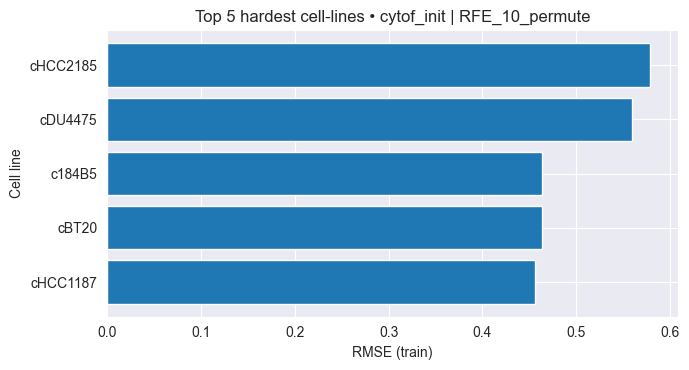

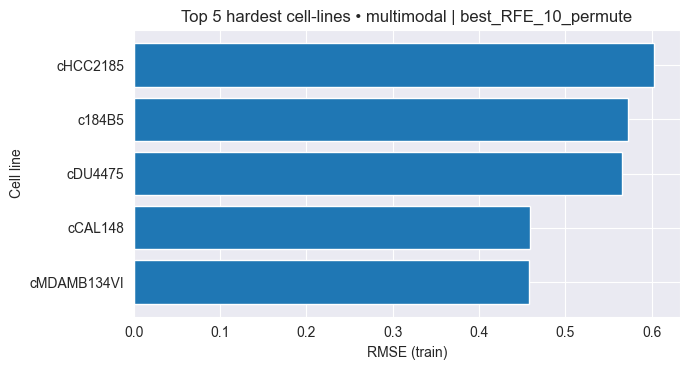

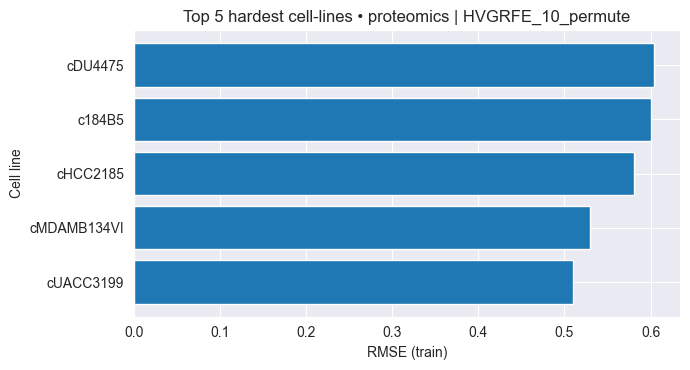

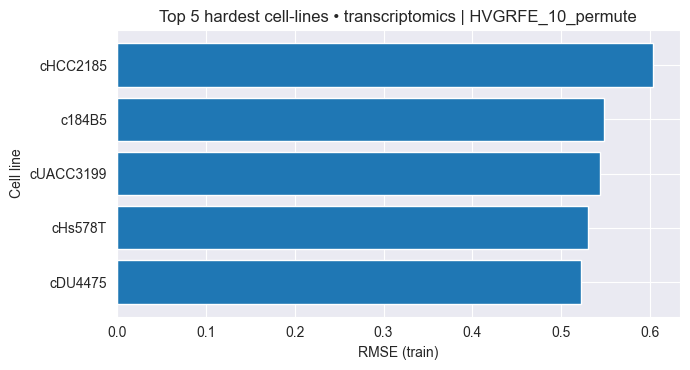

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from common import evaluations_dir

# ---- Load & aggregate --------------------------------------------------------
csv_path = evaluations_dir / model / data / "by_cl_cond_obs_figure1a.csv"
all_df = pd.read_csv(csv_path, index_col=0)

agg = (
    all_df.groupby(["sample", "dataset", "context", "features"], as_index=False)["rmse"]
    .mean()
)

# ---- Filter to train and take top-5 hardest per (context, features) ----------
train = agg[agg["dataset"] == "train"].copy()

# grab top 5 by rmse within each (context, features)
top5 = (
    train.sort_values("rmse", ascending=False)
         .groupby(["context", "features"], group_keys=True)
         .head(5)
         .reset_index(drop=True)
)

# For a quick tabular look if you want:
# display(top5.sort_values(["context", "features", "rmse"], ascending=[True, True, False]))

# ---- Plot: one clean chart per (context, features) ---------------------------
for (ctx, feats), df in top5.groupby(["context", "features"], sort=True):
    if ctx == "multimodal" and feats == "RFE_10_permute":
        continue  # skip suboptimal feature selection strategy for multimodal
    # order smallest-to-largest so the largest is at the top in the horizontal barh
    dplot = df.sort_values("rmse", ascending=True)

    plt.figure(figsize=(7, 3.8))  # compact, readable
    bars = plt.barh(dplot["sample"], dplot["rmse"])
    plt.xlabel("RMSE (train)")
    plt.ylabel("Cell line")
    plt.title(f"Top 5 hardest cell-lines • {ctx} | {feats}")
    plt.tight_layout()

    plt.show()